# Approach 1: Multiclass Baseline + Cancer-vs-Rest Specialist



This notebook documents the best true multi-classifier result from the experiments.



The final system combines two classifiers:



1. A 9-class PathMNIST multiclass baseline classifier.

2. A binary cancer-vs-rest specialist classifier.



The classifiers are combined with a validation-tuned specialist override rule. This approach achieved the best test cancer F2 among the classifier-combination experiments.

In [2]:
import json

import sys

from pathlib import Path



import numpy as np

import pandas as pd



# Make the notebook runnable from either the repository root or notebooks/.

def find_project_root(start):

    start = Path(start).resolve()

    candidates = [start, *start.parents]

    for candidate in candidates:

        if (candidate / 'pyproject.toml').exists() and (candidate / 'src' / 'pathmnist').exists():

            return candidate

    raise RuntimeError('Could not find project root containing pyproject.toml and src/pathmnist')



PROJECT_ROOT = find_project_root(Path.cwd())

SRC_DIR = PROJECT_ROOT / 'src'

if str(SRC_DIR) not in sys.path:

    sys.path.insert(0, str(SRC_DIR))



from pathmnist.data import dataset_meta

from pathmnist.metrics import compute_metrics, report_dict



BASELINE_DIR = PROJECT_ROOT / 'results' / 'baseline'

SPECIALIST_DIR = PROJECT_ROOT / 'results' / 'approach_01_cancer_vs_rest_specialist'

OVERRIDE_DIR = PROJECT_ROOT / 'results' / 'approach_01_cancer_vs_rest_override'

MODEL_DIR = PROJECT_ROOT / 'models' / 'approach_01_cancer_vs_rest_specialist'



meta = dataset_meta()

baseline_metrics = json.loads((BASELINE_DIR / 'metrics.json').read_text())

specialist_config = json.loads((SPECIALIST_DIR / 'config.json').read_text())

specialist_metrics = json.loads((SPECIALIST_DIR / 'specialist_metrics.json').read_text())

override_config = json.loads((OVERRIDE_DIR / 'config.json').read_text())

override_metrics = json.loads((OVERRIDE_DIR / 'metrics.json').read_text())



summary_keys = [

    'auc', 'acc', 'precision_macro', 'recall_macro', 'specificity_macro',

    'f1_macro', 'f2_macro', 'cancer_precision', 'cancer_recall',

    'cancer_specificity', 'cancer_f1', 'cancer_f2',

]

## Final Result



The approach improves the original baseline cancer F2 from `0.9204304581770748` to `0.9458159666559794` on the test split.



The absolute improvement is `+0.02538550847890464` cancer F2.



This is lower than the later true-224 single-classifier threshold result, but it is the best result that actually combines multiple classifiers.

In [3]:
rows = []

for name, metrics in [

    ('baseline multiclass classifier', baseline_metrics),

    ('approach 1 combined classifier', override_metrics),

]:

    test = metrics['test']

    rows.append({'model': name, **{key: test[key] for key in summary_keys}})



comparison = pd.DataFrame(rows)

comparison['delta_cancer_f2_vs_baseline'] = comparison['cancer_f2'] - comparison.loc[0, 'cancer_f2']

comparison

,model,auc,acc,precision_macro,recall_macro,specificity_macro,f1_macro,f2_macro,cancer_precision,cancer_recall,cancer_specificity,cancer_f1,cancer_f2,delta_cancer_f2_vs_baseline
0,baseline multiclass classifier,0.990435,0.911142,0.870790,0.875577,0.989062,0.870102,0.872685,0.940050,0.915653,0.987893,0.927691,0.920430,0.000000
1,approach 1 combined classifier,0.990476,0.911978,0.873881,0.871092,0.989063,0.868880,0.869478,0.903522,0.957015,0.978813,0.929500,0.945816,0.025386


## Dataset and Target



Dataset: PathMNIST from MedMNIST v2.



Resolution used for this multi-classifier approach: `28x28`.



Task: classify each histology patch into one of 9 tissue classes.



Cancer target class: label `8`, `colorectal adenocarcinoma epithelium`.



Why cancer F2 is the primary metric: F2 weights recall more strongly than precision. For this project, reducing false negatives for cancer is more important than maximizing plain accuracy.



Splits:



- train: `89,996` samples

- validation: `10,004` samples

- test: `7,180` samples



Validation was used for checkpoint selection and threshold tuning. Test labels were used only for final reporting.

In [4]:
for idx, name in enumerate(meta.class_names):

    print(f'{idx}: {name}')

0: adipose
1: background
2: debris
3: lymphocytes
4: mucus
5: smooth muscle
6: normal colon mucosa
7: cancer-associated stroma
8: colorectal adenocarcinoma epithelium


## Classifier 1: Multiclass Baseline



The first classifier is the already-trained baseline model. It predicts all 9 PathMNIST classes directly.



Baseline configuration:



- model: `small_cnn`

- classes: 9

- image size: `28x28`

- augmentation: `histology`

- epochs: `10`

- batch size: `512`

- optimizer: AdamW

- learning rate: `0.001`

- weight decay: `0.0001`

- label smoothing: `0.03`

- MixUp alpha: `0.05`

- class weights: none

- seed: `42`

- normalization: project PathMNIST mean/std

- selected checkpoint criterion in the training script: validation `AUC + accuracy`



The baseline produces a probability matrix `P_base` with shape `(n_samples, 9)`. Its default prediction is `argmax(P_base)`.

In [5]:
baseline_config = json.loads((BASELINE_DIR / 'config.json').read_text())

pd.Series(baseline_config)

model                             small_cnn
pretrained                            False
image_size                               28
augment                           histology
epochs                                   10
batch_size                              512
lr                                    0.001
weight_decay                         0.0001
optimizer                             adamw
momentum                                0.9
scheduler                            cosine
milestones                         [50, 75]
gamma                                   0.1
label_smoothing                        0.03
mixup_alpha                            0.05
class_weights                          none
seed                                     42
workers                                   0
device                                 auto
data_root                              data
norm                              pathmnist
results_dir                         results
models_dir                      

## Classifier 2: Cancer-vs-Rest Specialist



The second classifier is a separate binary model trained specifically for cancer detection.



It maps the original labels into:



- `0`: all non-cancer classes, original labels `0` through `7`

- `1`: cancer, original label `8`



Specialist configuration:



- model: `small_cnn`

- classes: 2

- image size: `28x28`

- augmentation: `histology`

- epochs: `10`

- batch size: `512`

- optimizer: AdamW

- learning rate: `0.0008`

- weight decay: `0.0001`

- label smoothing: `0.02`

- MixUp alpha: `0.05`

- class weights: balanced binary weights

- seed: `1042`

- checkpoint selection: validation binary F2 plus a small AUC tie contribution



The specialist produces a cancer probability `P_specialist(cancer)`. This probability is not a replacement for the 9-class classifier; it is used only to decide whether the baseline should be overridden to cancer.

In [6]:
pd.Series(specialist_config)

run_name           approach_01_cancer_vs_rest_specialist
type                           cancer_vs_rest_specialist
model                                          small_cnn
epochs                                                10
image_size                                            28
augment                                        histology
batch_size                                           512
lr                                                0.0008
weight_decay                                      0.0001
label_smoothing                                     0.02
mixup_alpha                                         0.05
seed                                                1042
device                                               mps
parameters                                        557122
dtype: object

In [7]:
pd.DataFrame(json.loads((SPECIALIST_DIR / 'history.json').read_text()))

,epoch,train_loss,binary_auc,binary_recall,binary_f2,lr
0,1,0.470875,0.971414,0.971369,0.772606,0.000780
1,2,0.352730,0.984773,0.821927,0.835463,0.000724
2,3,0.307085,0.992697,0.947626,0.924009,0.000635
3,4,0.283706,0.991056,0.953212,0.929204,0.000524
4,5,0.281075,0.995421,0.974860,0.946056,0.000400
5,6,0.269473,0.995950,0.946927,0.941536,0.000276
6,7,0.249291,0.995926,0.953911,0.946770,0.000165
7,8,0.250541,0.995939,0.956704,0.949806,0.000076
8,9,0.240158,0.996471,0.977654,0.954980,0.000020
9,10,0.247745,0.996328,0.972765,0.957520,0.000000


## How the Classifiers Are Combined



The combination is a decision-level override, not a simple average.



For each sample:



1. The multiclass baseline predicts 9-class probabilities `P_base`.

2. The binary specialist predicts cancer probability `s = P_specialist(cancer)`.

3. If `s >= threshold`, force the final prediction to class `8` cancer.

4. If `s < threshold`, keep the baseline multiclass prediction.



In implementation, forcing cancer means setting the cancer probability in the 9-class probability vector slightly above the current maximum probability, then re-normalizing. This keeps the saved artifact as a valid 9-class probability matrix while making `argmax` return cancer.



This strategy is useful because the baseline is good at general tissue classification, while the specialist is optimized to catch cancer cases that the baseline might miss.

In [8]:
print(json.dumps(override_config, indent=2))

{
  "approach": 1,
  "source_models": [
    "baseline",
    "approach_01_cancer_vs_rest_specialist"
  ],
  "specialist_threshold": 0.6399999999999999,
  "threshold_selection": {
    "cancer_f2": 0.9663807415605977,
    "cancer_recall": 0.9755586592178771
  },
  "min_validation_recall": 0.9581005586592178,
  "baseline_cancer_f2": 0.9204304581770748,
  "target_cancer_f2": 0.9304304581770748,
  "validation_only_selection": true
}


## Threshold Selection



The specialist override threshold was selected on validation only.



Selection rule:



1. Sweep thresholds from `0.05` to `0.95` in increments of `0.005`.

2. For each threshold, apply the override rule to validation predictions.

3. Compute validation cancer F2.

4. Require validation cancer recall to be at least the baseline validation cancer recall.

5. Pick the threshold with the highest validation cancer F2 under that recall constraint.



Selected threshold: `0.6399999999999999`.



Baseline validation cancer recall was `0.9581005586592178`. The selected override threshold achieved validation cancer recall `0.9755586592178771` and validation cancer F2 `0.9663807415605977`.

In [9]:
def normalize_probs(probs):

    probs = np.clip(probs, 1e-12, None)

    return probs / probs.sum(axis=1, keepdims=True)





def override_cancer(y_prob, cancer_score, threshold):

    out = y_prob.copy()

    mask = cancer_score >= threshold

    if np.any(mask):

        out[mask, 8] = np.maximum(out[mask].max(axis=1) + 1e-6, out[mask, 8])

    return normalize_probs(out)





def load_npz(path):

    arr = np.load(path)

    return arr['y_true'].reshape(-1).astype(int), arr['y_prob'].astype(float)



y_val, p_val_base = load_npz(BASELINE_DIR / 'val_predictions.npz')

y_test, p_test_base = load_npz(BASELINE_DIR / 'test_predictions.npz')

_, p_val_specialist = load_npz(SPECIALIST_DIR / 'specialist_val_predictions.npz')

_, p_test_specialist = load_npz(SPECIALIST_DIR / 'specialist_test_predictions.npz')



baseline_val = compute_metrics(y_val, p_val_base)

best = None

for threshold in np.linspace(0.05, 0.95, 181):

    p_val_combined = override_cancer(p_val_base, p_val_specialist[:, 1], float(threshold))

    m = compute_metrics(y_val, p_val_combined)

    if m.cancer_recall < baseline_val.cancer_recall:

        continue

    candidate = (m.cancer_f2, m.cancer_recall, float(threshold))

    if best is None or candidate > best:

        best = candidate



best

(0.9663807415605977, 0.9755586592178771, 0.6399999999999999)

## Recomputing the Final Predictions



The following cell recomputes the combined validation and test probabilities from the saved baseline and specialist predictions. It should match the saved `approach_01_cancer_vs_rest_override` metrics.

In [10]:
threshold = override_config['specialist_threshold']

p_val_combined = override_cancer(p_val_base, p_val_specialist[:, 1], threshold)

p_test_combined = override_cancer(p_test_base, p_test_specialist[:, 1], threshold)



recomputed = {

    'val_cancer_f2': compute_metrics(y_val, p_val_combined).cancer_f2,

    'test_cancer_f2': compute_metrics(y_test, p_test_combined).cancer_f2,

    'saved_val_cancer_f2': override_metrics['val']['cancer_f2'],

    'saved_test_cancer_f2': override_metrics['test']['cancer_f2'],

}

recomputed

{'val_cancer_f2': 0.9663807415605977,
 'test_cancer_f2': 0.9458159666559794,
 'saved_val_cancer_f2': 0.9663807415605977,
 'saved_test_cancer_f2': 0.9458159666559794}

## Final Test Metrics



The combined classifier improved cancer recall and cancer F2 compared with the baseline.



Trade-off: cancer precision decreased from the baseline because the specialist intentionally flags additional probable cancer cases. That is expected for an F2-oriented system, because F2 rewards recall more heavily than precision.

In [11]:
final_test = pd.Series({key: override_metrics['test'][key] for key in summary_keys})

final_test

auc                   0.990476
acc                   0.911978
precision_macro       0.873881
recall_macro          0.871092
specificity_macro     0.989063
f1_macro              0.868880
f2_macro              0.869478
cancer_precision      0.903522
cancer_recall         0.957015
cancer_specificity    0.978813
cancer_f1             0.929500
cancer_f2             0.945816
dtype: float64

In [12]:
confusion = pd.DataFrame(

    override_metrics['test']['confusion_matrix'],

    index=[f'true_{i}_{name}' for i, name in enumerate(meta.class_names)],

    columns=[f'pred_{i}_{name}' for i, name in enumerate(meta.class_names)],

)

confusion

,pred_0_adipose,pred_1_background,pred_2_debris,pred_3_lymphocytes,pred_4_mucus,pred_5_smooth muscle,pred_6_normal colon mucosa,pred_7_cancer-associated stroma,pred_8_colorectal adenocarcinoma epithelium
true_0_adipose,1326,5,1,0,2,3,0,0,1
true_1_background,0,847,0,0,0,0,0,0,0
true_2_debris,0,0,278,1,0,18,1,40,1
true_3_lymphocytes,0,0,2,626,0,0,1,0,5
true_4_mucus,54,14,1,0,945,1,5,10,5
true_5_smooth muscle,0,0,40,0,15,492,0,45,0
true_6_normal colon mucosa,0,2,3,12,4,0,671,1,48
true_7_cancer-associated stroma,0,0,72,3,1,94,2,183,66
true_8_colorectal adenocarcinoma epithelium,0,0,13,20,4,6,8,2,1180


## Visualized Confusion Matrix



The table above is useful for exact values, but the heatmaps below make the error structure easier to inspect. The first plot shows raw test counts. The second plot normalizes each row, so each row shows where samples from one true class were predicted.

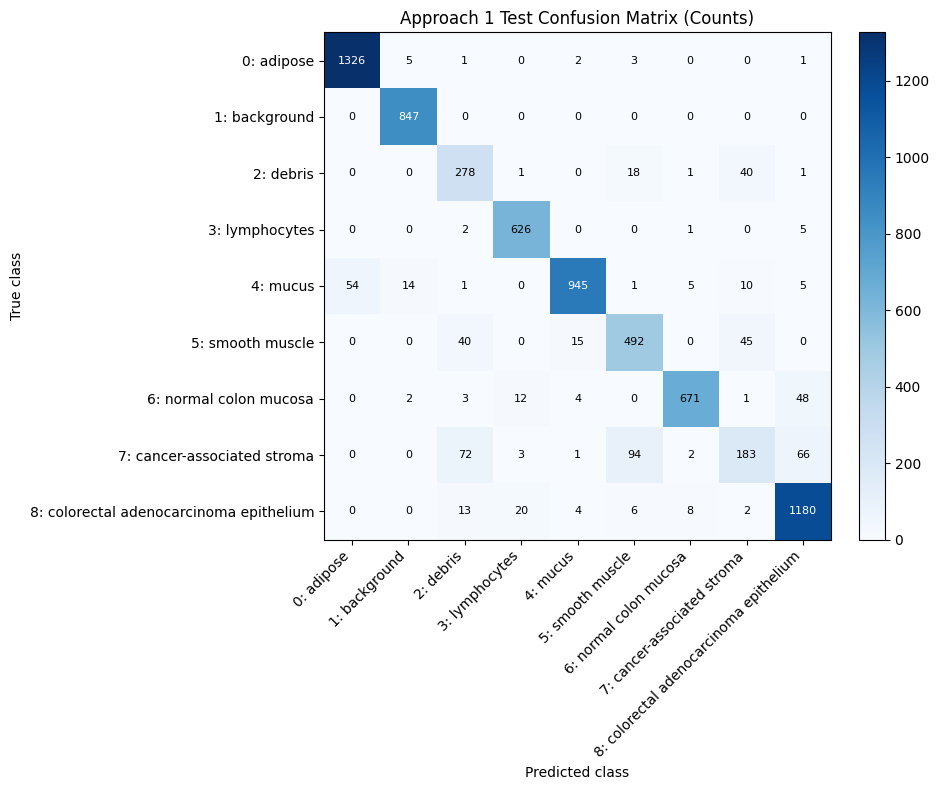

In [13]:
import matplotlib.pyplot as plt



cm = np.asarray(override_metrics['test']['confusion_matrix'])

class_labels = [f'{i}: {name}' for i, name in enumerate(meta.class_names)]



fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm, cmap='Blues')

ax.set_title('Approach 1 Test Confusion Matrix (Counts)')

ax.set_xlabel('Predicted class')

ax.set_ylabel('True class')

ax.set_xticks(np.arange(len(class_labels)))

ax.set_yticks(np.arange(len(class_labels)))

ax.set_xticklabels(class_labels, rotation=45, ha='right')

ax.set_yticklabels(class_labels)



threshold_text = cm.max() * 0.55

for i in range(cm.shape[0]):

    for j in range(cm.shape[1]):

        color = 'white' if cm[i, j] > threshold_text else 'black'

        ax.text(j, i, int(cm[i, j]), ha='center', va='center', color=color, fontsize=8)



fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

plt.show()

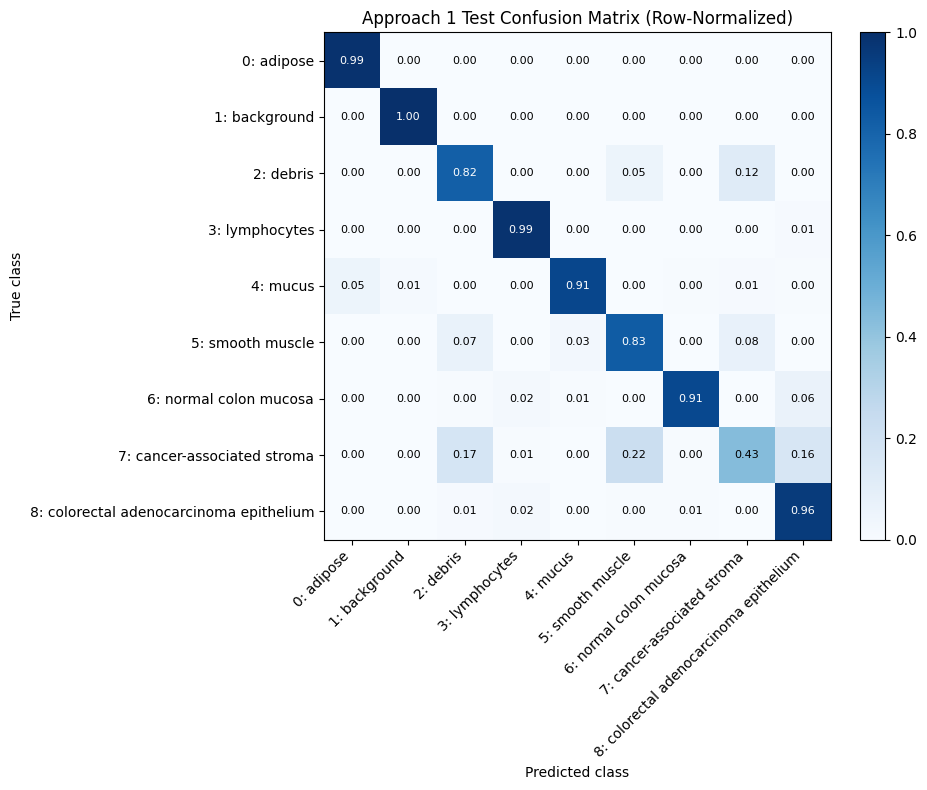

In [14]:
cm_norm = cm / cm.sum(axis=1, keepdims=True)



fig, ax = plt.subplots(figsize=(10, 8))

im = ax.imshow(cm_norm, cmap='Blues', vmin=0, vmax=1)

ax.set_title('Approach 1 Test Confusion Matrix (Row-Normalized)')

ax.set_xlabel('Predicted class')

ax.set_ylabel('True class')

ax.set_xticks(np.arange(len(class_labels)))

ax.set_yticks(np.arange(len(class_labels)))

ax.set_xticklabels(class_labels, rotation=45, ha='right')

ax.set_yticklabels(class_labels)



for i in range(cm_norm.shape[0]):

    for j in range(cm_norm.shape[1]):

        value = cm_norm[i, j]

        color = 'white' if value > 0.55 else 'black'

        ax.text(j, i, f'{value:.2f}', ha='center', va='center', color=color, fontsize=8)



fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04)

fig.tight_layout()

plt.show()

## Interpreting the CNN Features

The CNN does not expose human-readable features such as "gland shape" or "nuclei density" directly. Instead, it learns convolutional feature maps. Early feature maps tend to respond to local color and edge patterns, while deeper feature maps combine those local responses into more task-specific tissue patterns.

For this approach, the most relevant model to inspect is the cancer-vs-rest specialist, because it is the classifier that triggers the cancer override. The cells below load the saved specialist checkpoint, choose a real cancer sample from the test set, visualize selected internal feature maps, and compute a Grad-CAM heatmap for the specialist's cancer logit.

In [15]:
import torch
import torch.nn.functional as F
from torchvision.transforms.functional import to_pil_image

from pathmnist.data import build_dataset
from pathmnist.models import build_model

SPECIALIST_CHECKPOINT = MODEL_DIR / 'best.pt'
checkpoint = torch.load(SPECIALIST_CHECKPOINT, map_location='cpu')
specialist_model = build_model('small_cnn', 2, pretrained=False)
specialist_model.load_state_dict(checkpoint['model'])
specialist_model.eval()

# Use unaugmented test data, matching evaluation.
test_dataset = build_dataset(
    'test',
    image_size=specialist_config['image_size'],
    source_size=specialist_config.get('source_size'),
    augment='none',
    root=str(PROJECT_ROOT / 'data'),
    norm='pathmnist',
)

# Select a true cancer sample with high specialist cancer probability.
_, specialist_test_probs = load_npz(SPECIALIST_DIR / 'specialist_test_predictions.npz')
test_labels = np.asarray(test_dataset.labels).reshape(-1).astype(int)
cancer_indices = np.where(test_labels == 8)[0]
selected_index = int(cancer_indices[np.argmax(specialist_test_probs[cancer_indices, 1])])
x, y = test_dataset[selected_index]
print({'selected_test_index': selected_index, 'true_label': int(np.asarray(y).reshape(-1)[0]), 'specialist_cancer_probability': float(specialist_test_probs[selected_index, 1])})

{'selected_test_index': 3991, 'true_label': 8, 'specialist_cancer_probability': 0.9999996423721313}


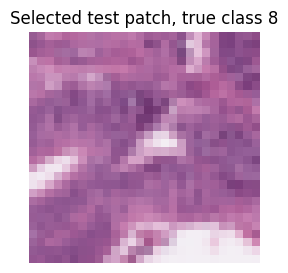

In [16]:
def unnormalize_image(x_tensor):
    mean = torch.tensor(meta.mean).view(3, 1, 1)
    std = torch.tensor(meta.std).view(3, 1, 1)
    image = x_tensor.cpu() * std + mean
    return image.clamp(0, 1)

image = unnormalize_image(x)
plt.figure(figsize=(3, 3))
plt.imshow(np.transpose(image.numpy(), (1, 2, 0)))
plt.title(f'Selected test patch, true class {int(np.asarray(y).reshape(-1)[0])}')
plt.axis('off')
plt.show()

In [17]:
# Capture feature maps after representative activation layers.
feature_layers = {
    'early_layer_2_silu': specialist_model.net[2],
    'middle_layer_9_silu': specialist_model.net[9],
    'deep_layer_16_silu': specialist_model.net[16],
}
activations = {}
hooks = []
for name, layer in feature_layers.items():
    hooks.append(layer.register_forward_hook(lambda module, inputs, output, layer_name=name: activations.__setitem__(layer_name, output.detach().cpu())))

with torch.no_grad():
    logits = specialist_model(x.unsqueeze(0))
    probabilities = torch.softmax(logits, dim=1).squeeze().cpu().numpy()

for hook in hooks:
    hook.remove()

print({'non_cancer_probability': float(probabilities[0]), 'cancer_probability': float(probabilities[1])})

{'non_cancer_probability': 3.879983978549717e-07, 'cancer_probability': 0.9999996423721313}


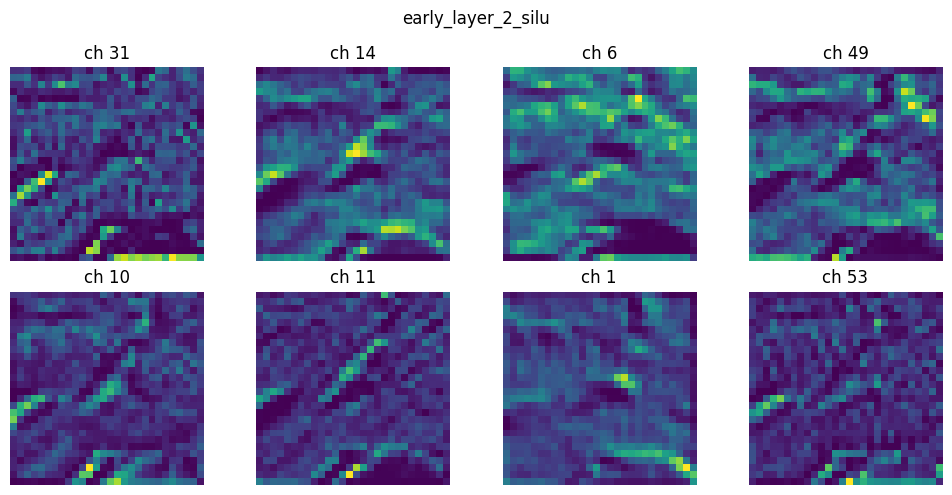

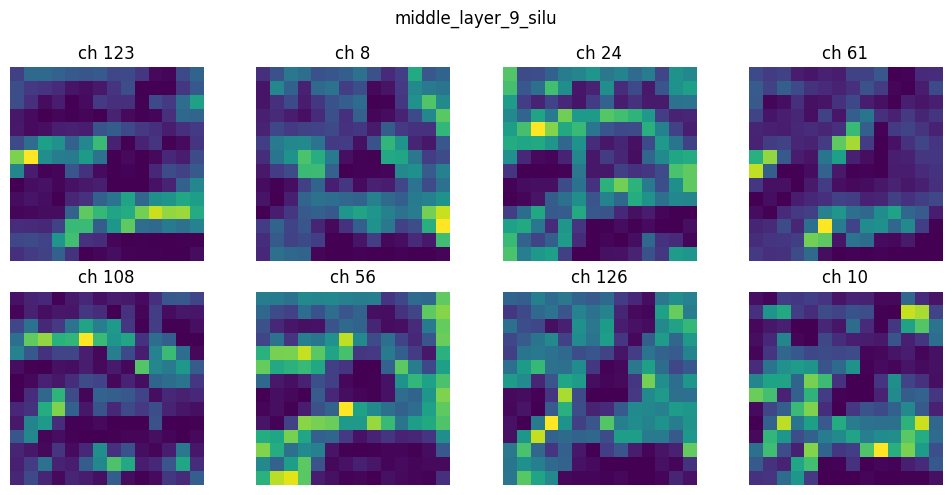

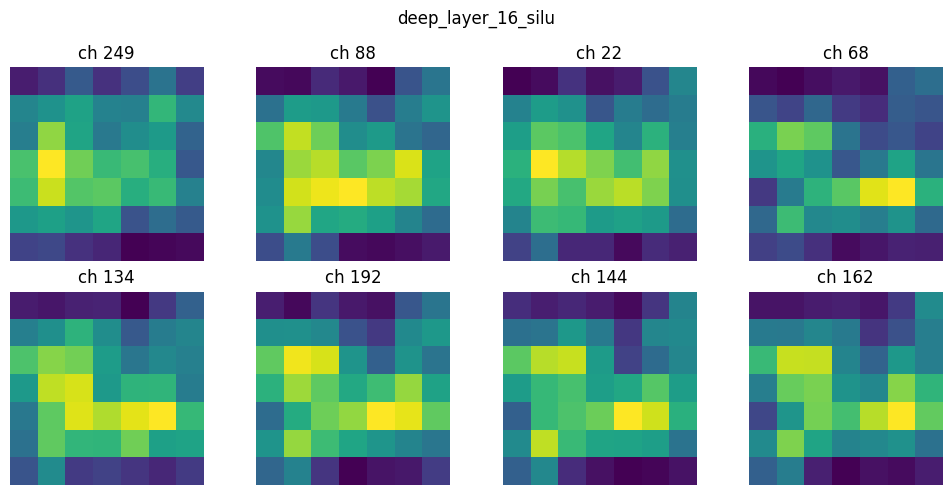

In [18]:
def plot_top_feature_maps(layer_name, activation, top_k=8):
    maps = activation.squeeze(0)
    scores = maps.flatten(1).mean(dim=1)
    top_indices = torch.topk(scores, k=min(top_k, maps.shape[0])).indices.tolist()
    cols = 4
    rows = int(np.ceil(len(top_indices) / cols))
    fig, axes = plt.subplots(rows, cols, figsize=(10, 2.5 * rows))
    axes = np.asarray(axes).reshape(-1)
    for ax, channel_idx in zip(axes, top_indices):
        feature_map = maps[channel_idx].numpy()
        ax.imshow(feature_map, cmap='viridis')
        ax.set_title(f'ch {channel_idx}')
        ax.axis('off')
    for ax in axes[len(top_indices):]:
        ax.axis('off')
    fig.suptitle(layer_name)
    fig.tight_layout()
    plt.show()

for layer_name, activation in activations.items():
    plot_top_feature_maps(layer_name, activation)

## Grad-CAM for the Cancer Specialist

Feature maps show which internal channels activate, but they do not directly say which image regions influenced the cancer decision. Grad-CAM is more useful for that: it uses the gradient of the cancer logit with respect to the last convolutional feature map to produce a coarse spatial heatmap.

The heatmap below should be interpreted as a model-attention diagnostic, not as a clinical explanation. On `28x28` inputs it is necessarily coarse, but it can still reveal whether the specialist is focusing on tissue regions rather than background or obvious artifacts.

In [19]:
def specialist_grad_cam(model, x_tensor, target_class=1, target_layer_index=16):
    model.eval()
    model.zero_grad(set_to_none=True)

    z = x_tensor.unsqueeze(0)
    target_activation = None
    for layer_index, layer in enumerate(model.net):
        z = layer(z)
        if layer_index == target_layer_index:
            target_activation = z.clone()
            target_activation.retain_grad()
            z = target_activation

    logits = model.head(z)
    score = logits[0, target_class]
    score.backward()

    activation = target_activation.detach()
    gradient = target_activation.grad.detach()
    weights = gradient.mean(dim=(2, 3), keepdim=True)
    cam = (weights * activation).sum(dim=1, keepdim=True)
    cam = F.relu(cam)
    cam = F.interpolate(cam, size=x_tensor.shape[-2:], mode='bilinear', align_corners=False)
    cam = cam.squeeze().cpu().numpy()
    cam = (cam - cam.min()) / (cam.max() - cam.min() + 1e-12)
    probabilities = torch.softmax(logits.detach(), dim=1).squeeze().cpu().numpy()
    return cam, probabilities

cam, gradcam_probs = specialist_grad_cam(specialist_model, x, target_class=1)
print({'gradcam_non_cancer_probability': float(gradcam_probs[0]), 'gradcam_cancer_probability': float(gradcam_probs[1])})

{'gradcam_non_cancer_probability': 3.879983978549717e-07, 'gradcam_cancer_probability': 0.9999996423721313}


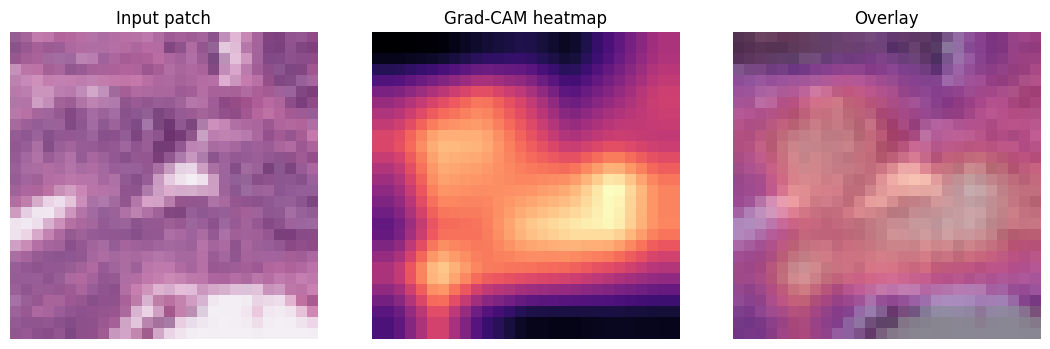

In [20]:
image_np = np.transpose(image.numpy(), (1, 2, 0))

fig, axes = plt.subplots(1, 3, figsize=(11, 3.5))
axes[0].imshow(image_np)
axes[0].set_title('Input patch')
axes[0].axis('off')

axes[1].imshow(cam, cmap='magma')
axes[1].set_title('Grad-CAM heatmap')
axes[1].axis('off')

axes[2].imshow(image_np)
axes[2].imshow(cam, cmap='magma', alpha=0.45)
axes[2].set_title('Overlay')
axes[2].axis('off')

fig.tight_layout()
plt.show()

## Why This Is a Multi-Classifier Approach



This approach uses two independently trained classifiers with different tasks:



- The baseline is a multiclass tissue classifier. It learns the full 9-class PathMNIST problem.

- The specialist is a binary cancer detector. It learns a different decision boundary: cancer versus every other tissue type.



The final prediction depends on both outputs. The baseline handles normal multiclass recognition, while the specialist can override the baseline when its cancer probability is high enough. This makes the final classifier a hybrid/cascade system rather than a single model.



The method is intentionally simple and defensible:



- no test labels are used for threshold selection

- the override threshold is explicit

- the specialist has a clear role: reduce cancer false negatives

- the baseline remains responsible for non-cancer class discrimination unless the specialist is confident enough to override

## Research Origin of This Idea



This approach is supported by the research notes in the `data/` folder, but it should be described as an evidence-based synthesis rather than a direct reproduction of one single paper.



The closest local source is `data/research.md`. Its executive summary recommends a recall-first pipeline that keeps the standard 9-way PathMNIST classifier for comparability, adds a dedicated **TUM-vs-rest** cancer component, calibrates or tunes scores on the validation set, and optimizes the decision threshold under an explicit recall constraint. Our approach implements a practical two-model version of that recommendation:



- `data/research.md`, lines 9-11: discusses binarized cancer-vs-non-cancer sensitivity and recommends retaining the 9-way task while adding a dedicated TUM-vs-rest component plus validation threshold optimization.

- `data/research.md`, lines 46-52: identifies one-vs-rest classifiers, calibration/threshold tuning, cascaded models, and post-hoc threshold optimization as recall-oriented tools; it frames PathMNIST as a hard-negative and decision-threshold problem rather than only a class-imbalance problem.

- `data/research.md`, lines 56-78: proposes a recall-first pipeline with a multiclass 9-way head, an auxiliary TUM-vs-rest head, validation-set calibration, and post-hoc threshold optimization.

- `data/experiment-design.md`, lines 153-176: defines the recall-oriented experiment and explicitly says that cancer-vs-rest threshold tuning may be added using validation predictions only.



The paper-level motivation summarized in those notes comes mainly from:



1. The original PathMNIST / colorectal histology source work by Kather et al., which establishes the 9-class colorectal tissue classification setup and external validation framing.

2. The official MedMNIST benchmark papers, which make the 9-way PathMNIST task and train/validation/test split comparable across methods.

3. The ViT-Base-Patch16-224 PathMNIST study summarized in `data/research.md`, which reports class-wise cancer precision/recall/F1 and shows that cancer false negatives are concentrated in specific neighboring tissue classes.

4. The risk-aware noisy-label PathMNIST work summarized in `data/research.md`, which supports binarized cancer-vs-non-cancer sensitivity optimization and cost-sensitive recall-oriented learning, while warning that specificity can collapse if the operating point is too aggressive.

5. The MedMNIST+ discussion summarized in `data/research.md`, which motivates treating threshold choice as an application-specific operating point rather than relying only on fixed argmax accuracy.



Therefore, the notebook's approach is best written as: **a benchmark-compatible 9-class classifier plus a separately trained cancer-vs-rest specialist, combined by validation-only threshold tuning**. This is not exactly the same as the proposed single-backbone auxiliary-head design in the research notes, but it implements the same principle with two independently trained classifiers: preserve 9-class tissue recognition, then add a cancer-focused decision component to reduce false negatives.

## Exact Reproduction Commands



First reproduce the baseline if needed:



```bash

PYTHONPATH=src python -m pathmnist.train \

  --model small_cnn \

  --image-size 28 \

  --augment histology \

  --epochs 10 \

  --batch-size 512 \

  --lr 0.001 \

  --weight-decay 0.0001 \

  --optimizer adamw \

  --label-smoothing 0.03 \

  --mixup-alpha 0.05 \

  --class-weights none \

  --seed 42 \

  --workers 0 \

  --device auto \

  --data-root data \

  --norm pathmnist \

  --results-dir results \

  --models-dir models \

  --run-name baseline \

  --target-auc 0.99 \

  --target-acc 0.911 \

  --no-progress

```



Then train/evaluate approach 1:



```bash

PYTHONPATH=src python scripts/approach_01_cancer_vs_rest.py \

  --epochs 10 \

  --batch-size 512 \

  --lr 0.0008 \

  --weight-decay 0.0001 \

  --label-smoothing 0.02 \

  --mixup-alpha 0.05 \

  --seed 1042 \

  --workers 0 \

  --device auto \

  --data-root data

```



Important artifacts:



- baseline checkpoint: `models/baseline/best.pt`

- baseline validation predictions: `results/baseline/val_predictions.npz`

- baseline test predictions: `results/baseline/test_predictions.npz`

- specialist checkpoint: `models/approach_01_cancer_vs_rest_specialist/best.pt`

- specialist validation predictions: `results/approach_01_cancer_vs_rest_specialist/specialist_val_predictions.npz`

- specialist test predictions: `results/approach_01_cancer_vs_rest_specialist/specialist_test_predictions.npz`

- combined predictions: `results/approach_01_cancer_vs_rest_override/val_predictions.npz` and `test_predictions.npz`

- final metrics: `results/approach_01_cancer_vs_rest_override/metrics.json`